In [1]:
from quadcoil import (
    quadcoil, SurfaceJAX, QuadcoilParams, 
    least_square_meshing, 
    SurfaceRZFourierJAX, SurfaceXYZTensorFourierJAX,
    project_points_to_rz_plane,
    project_points_to_plane,
    project_points_to_known_plane,
    raytrace_to_plane,
    max_lse,
    reconstruct_3d_from_plane
)
from quadcoil.winding_surface import _polygon_self_intersection, bisect_phi
from quadcoil.quantity import K_theta, Phi_with_net_current, K2, K
from quadcoil.io import simsopt_coil_from_qp
from quadcoil.plotting import gamma_to_vtk, gamma_and_scalar_field_to_vtk, gamma_and_field_to_vtk
from jax import jit, eval_shape, vmap
from functools import partial
from interpax import interp2d

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
import time
import lineax as lx

In [3]:
from simsopt import load
from simsopt.geo import curves_to_vtk
from simsopt.field import BiotSavart
from simsopt.objectives.fluxobjective import SquaredFlux

## Loading data

In [4]:
# The example is li383.
_, plasma_surface = load('surfaces.json')
net_poloidal_current_amperes = 11884578.094260072
import jax
jax.config.update('jax_enable_x64', True)
# plasma_surface_jax = SurfaceJAX.from_simsopt(plasma_surface)
plasma_surface_jax = SurfaceJAX.from_simsopt(load('serial1149928.json')[0][1])

<class 'quadcoil.surface.SurfaceXYZTensorFourierJAX'>


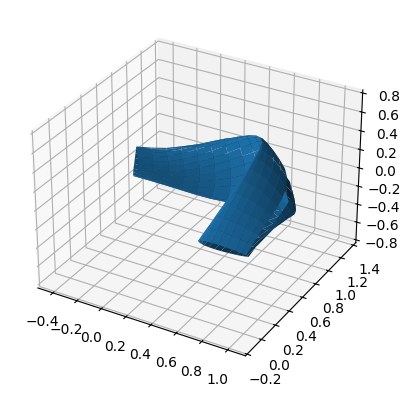

In [5]:
print(type(plasma_surface_jax))
plasma_surface_jax.plot()

In [6]:
plasma_surface_jax.stellsym

True

In [7]:
fit_surface = plasma_surface_jax.gen_winding_surface(
    d_expand=-.2,
    mpol=7,
    ntor=7,
    phi_interp=2,
    theta_interp=5,
    theta_rule_subsample=5,
    lam_tikhonov=1e-3,
    quadpoints_phi = jnp.linspace(0, 1, plasma_surface_jax.nfp * 100),
    quadpoints_theta = jnp.linspace(0, 1, 100),
    rule='self-intersection',
    theta_mode='arctan',
)

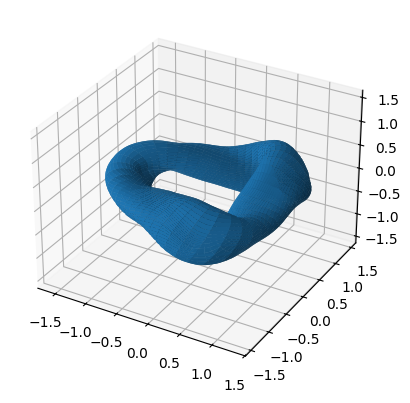

In [8]:
fit_surface.plot()
fit_surface.to_simsopt().to_vtk('fit_surface')

# Testing on tensor surface

In [9]:
%%time
phi_grid, theta_grid = least_square_meshing(
    surf=plasma_surface_jax, 
    quadpoints_phi_offset=quadpoints_phi_offset, 
    quadpoints_theta_offset=quadpoints_theta_offset, 
    mpol=6, ntor=6, 
    d_expand=0.2
)

CPU times: user 7 μs, sys: 0 ns, total: 7 μs
Wall time: 11 μs


NameError: name 'quadpoints_phi_offset' is not defined

In [ ]:
gamma_and_scalar_field_to_vtk(gamma_uniform, phi_grid, 'phi_grid')
gamma_and_scalar_field_to_vtk(gamma_uniform, theta_grid, 'theta_grid')
gamma_and_scalar_field_to_vtk(gamma_uniform, da, 'da')

In [ ]:
(
    gamma_offset,
    dphi, dtheta, da,
    quadpoints_phi_rolled, 
    quadpoints_theta_rolled
) = self._gamma_offset(
    d_expand, 
    phi_interp=phi_interp,
    theta_interp=theta_interp,
    endpoint=True
)


In [ ]:
offset2 = plasma_surface_jax2.uniform_offset(
    d_expand=-0, 
    mpol=7, ntor=7,
    quadpoints_phi=jnp.linspace(0, 1, 300), 
    quadpoints_theta=jnp.linspace(0, 1, 100), 
    phi_interp=2, theta_interp=2,
)
offset2.to_simsopt().to_vtk('test2')
(
    gamma_uniform2, _, 
    quadpoints_phi_offset2, 
    quadpoints_theta_offset2
) = plasma_surface_jax2._gamma_offset(
    d_expand=-.0, 
    phi_interp=2,
    theta_interp=2,
)
phi_grid2, theta_grid2 = least_square_meshing(
    surf=plasma_surface_jax2, 
    quadpoints_phi_offset=quadpoints_phi_offset2, 
    quadpoints_theta_offset=quadpoints_theta_offset2, 
    mpol=7, ntor=7, 
    d_expand=-0.0
)
gamma_and_scalar_field_to_vtk(gamma_uniform2, phi_grid2, 'phi_grid2')
gamma_and_scalar_field_to_vtk(gamma_uniform2, theta_grid2, 'theta_grid2')

In [ ]:
plasma_surface_jax2

# Failed experiments

In [ ]:
@jit
def iterate_phi2(phi_grid, damping_factor=1.):
    """Second-order (Halley) Newton iteration in phi.

    For each (i, j) on the (n_phi, n_theta) grid, shift phi so that
    ``offset_surface.gamma_at_point(phi_grid_new, theta_grid)[i, j]`` lies on
    the i-th plane in ``plane_data``.  The root of

        f(phi) = (gamma(phi, theta_ij) - origin_i) . normal_i

    is updated with one Halley step

        phi <- phi - 2 f f' / (2 (f')^2 - f f'')

    using first and second phi-derivatives obtained from
    ``offset_surface.gammadash_at_point(., ., a, 0)`` with ``a = 1, 2``.
    """
    gamma = offset_surface.gamma_at_point(phi_grid, theta_grid)
    g1    = offset_surface.gammadash_at_point(phi_grid, theta_grid, 1, 0)
    g11   = offset_surface.gammadash_at_point(phi_grid, theta_grid, 2, 0)

    o = plane_data['origin'][:, None, :]
    n = plane_data['normal'][:, None, :]

    f   = jnp.sum((gamma - o) * n, axis=-1)
    fp  = jnp.sum(g1  * n, axis=-1)
    fpp = jnp.sum(g11 * n, axis=-1)

    delta_phi = -2.0 * f * fp / (2.0 * fp * fp - f * fpp)
    return phi_grid + damping_factor * delta_phi


phi_grid2_halley = iterate_phi(phi_grid, damping_factor=0.5)
gamma_pol_halley = offset_surface.gamma_at_point(phi_grid2_halley, theta_grid)
gamma_and_scalar_field_to_vtk(gamma_pol_halley, phi_grid, 'gamma_halley')

In [ ]:
plasma_surface_sym = plasma_surface_jax.copy_and_set_quadpoints(
    quadpoints_phi=quadpoints_phi, 
    quadpoints_theta=quadpoints_theta, 
)
source_curvatures = plasma_surface_sym.surface_curvatures()

In [67]:
source_curvatures.shape

(32, 64, 4)

In [68]:
weight = jnp.where()

TypeError: where() missing 1 required positional argument: 'condition'

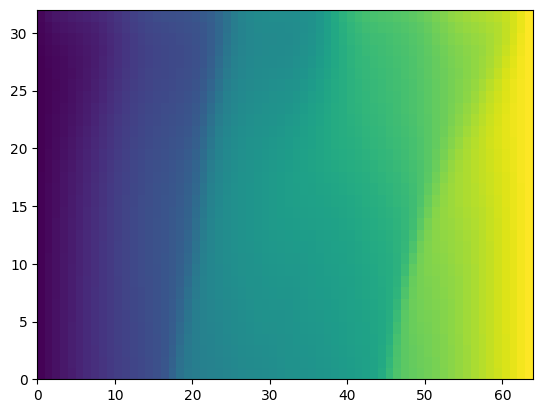

In [70]:
plt.pcolor(arclengths)

In [72]:
unitnormal_uniform = offset_surface.unitnormal()
jacobian = jnp.sum(unitnormal_uniform*jnp.cross(gammadash1_uniform, gammadash2_uniform, axis=-1), axis=-1)
gamma_to_vtk(gamma_uniform, 'test_gamma')
gamma_to_vtk(gamma_uniform2, 'test_gamma2')
gamma_and_field_to_vtk(gamma_uniform, gammadash1_uniform, 'gammadash1_uniform')
gamma_and_field_to_vtk(gamma_uniform, unitnormal_uniform, 'unitnormal_uniform')
gamma_and_scalar_field_to_vtk(gamma_uniform, theta_grid, 'theta_grid')
gamma_and_scalar_field_to_vtk(gamma_uniform, source_curvatures[:, :, 0], 'source_curvatures0')
gamma_and_scalar_field_to_vtk(gamma_uniform, source_curvatures[:, :, 1], 'source_curvatures1')
gamma_and_scalar_field_to_vtk(gamma_uniform, source_curvatures[:, :, 2], 'source_curvatures2')
gamma_and_scalar_field_to_vtk(gamma_uniform, source_curvatures[:, :, 3], 'source_curvatures3')
gamma_and_scalar_field_to_vtk(plasma_surface_sym.gamma(), source_curvatures[:, :, 0], 'plasma_curvatures0')
gamma_and_scalar_field_to_vtk(plasma_surface_sym.gamma(), source_curvatures[:, :, 1], 'plasma_curvatures1')
gamma_and_scalar_field_to_vtk(plasma_surface_sym.gamma(), source_curvatures[:, :, 2], 'plasma_curvatures2')
gamma_and_scalar_field_to_vtk(plasma_surface_sym.gamma(), source_curvatures[:, :, 3], 'plasma_curvatures3')
gamma_and_scalar_field_to_vtk(plasma_surface_sym.gamma(), jnp.where(source_curvatures[:, :, 2]>1/d_expand, source_curvatures[:, :, 3], 0), 'plasma_C')
gamma_and_scalar_field_to_vtk(gamma_uniform, jnp.where(source_curvatures[:, :, 2]>1/d_expand, source_curvatures[:, :, 3], 0), 'plasma_C2')
gamma_and_scalar_field_to_vtk(gamma_uniform, jacobian, 'jacobian_uniform')
gamma_and_scalar_field_to_vtk(gamma_uniform, arclengths, 'arclengths')


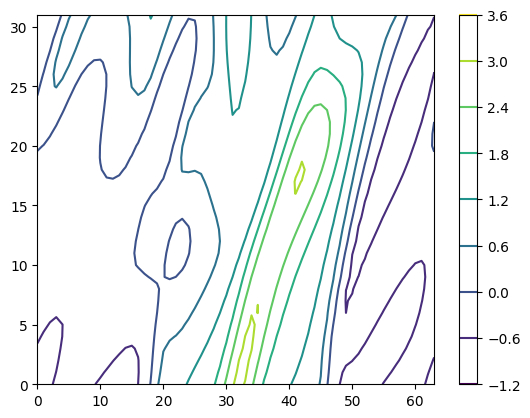

In [73]:
plt.contour(source_curvatures[:, :, 2])
plt.colorbar()

In [74]:
1/d_expand

1.6666666666666667

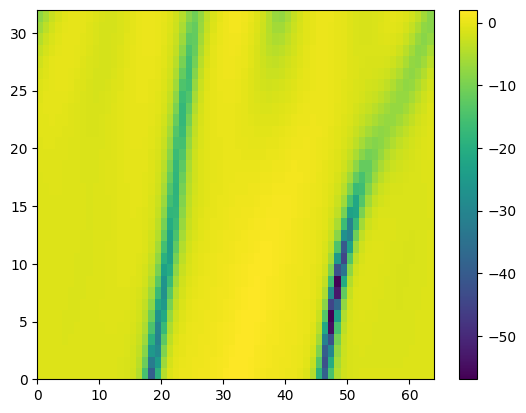

In [75]:
plt.pcolor(source_curvatures[:, :, 0])
plt.colorbar()


In [76]:
delta_phi = batched_raytrace(gamma_uniform, gammadash1_uniform, plane_data)
gamma_and_scalar_field_to_vtk(gamma_uniform, delta_phi, 'delta_phi')

In [77]:
def iterate_phi(phi_grid_in, damping_factor=0.1):
    gamma_sample = offset_surface.gamma_at_point(phi_grid_in, theta_grid)
    gammadash1_sample = offset_surface.gammadash_at_point(phi_grid_in, theta_grid, 1, 0)
    delta_phi = batched_raytrace(gamma_sample, gammadash1_sample, plane_data)
    return phi_grid + damping_factor * delta_phi
# Shifting phi grid via a Newton iteration so that
# points projected from the same poloidal slice also ends
# up in the same fitted surface.


In [78]:
phi_grid_in = phi_grid
gamma_sample = offset_surface.gamma_at_point(phi_grid_in, theta_grid)
gammadash1_sample = offset_surface.gammadash_at_point(phi_grid_in, theta_grid, 1, 0)
gammadash2_sample = offset_surface.gammadash_at_point(phi_grid_in, theta_grid, 0, 1)
gammadash1_unit = gammadash1_sample / jnp.linalg.norm(gammadash1_sample, axis=-1)[:, :, None]
gammadash2_unit = gammadash2_sample / jnp.linalg.norm(gammadash2_sample, axis=-1)[:, :, None]
shear = jnp.linalg.norm(jnp.cross(gammadash1_unit, gammadash2_unit, axis=-1), axis=-1)
delta_phi = batched_raytrace(gamma_sample, gammadash1_sample, plane_data)
# return phi_grid + damping_factor * shear * delta_phi

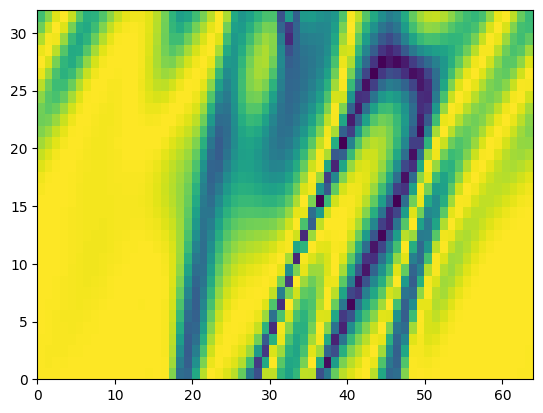

In [79]:
plt.pcolor(shear)

In [ ]:
grid_phi

In [48]:

gamma_and_scalar_field_to_vtk(gamma_sample, grid_phi, 'phi_grid_bisection')

In [54]:
damping_factor = 0.5
phi_grid2 = iterate_phi(phi_grid, damping_factor)
phi_grid3 = iterate_phi(phi_grid2, damping_factor)
phi_grid4 = iterate_phi(phi_grid3, damping_factor)

gamma_pol_2 = offset_surface.gamma_at_point(phi_grid2, theta_grid)
gamma_pol_3 = offset_surface.gamma_at_point(phi_grid3, theta_grid)
gamma_pol_4 = offset_surface.gamma_at_point(phi_grid4, theta_grid)


gamma_and_scalar_field_to_vtk(gamma_pol_2, phi_grid, 'gamma_pol_2')
gamma_and_scalar_field_to_vtk(gamma_pol_3, phi_grid, 'gamma_pol_3')
gamma_and_scalar_field_to_vtk(gamma_pol_4, phi_grid, 'gamma_pol_4')